![display relevant image here](Financial_Loan_Risk_Image4.jpg)


# FinTech Innovations - Complete Credit Risk Modeling Pipeline


## Overview

We developed a reliable automated machine learning pipeline using a Random Forest Classifier to predict credit risk and support loan approval decisions. The model achieves a robust performance when predicting credit reliability. The most critical factors driving these decisions are a borrower's Total Debt-to-Income Ratio, Monthly/Annual Income, and Interest Rates, providing clear actionable insights for underwriting.

By utilizing a pipeline with strict preprocessing, hyperparameter tuning, and cross-validation, the classification model cleanly separates reliable borrowers from high-risk ones. Implementing this model minimizes manual review time, reducing human bias and operational costs. Most importantly, it balances the risk of financial loss from bad loans (False Positives) against the loss of profitable business from rejecting good customers (False Negatives), ultimately protecting FinTech Innovations bottom line. 

FinTech Innovations is transitioning from a slow, manual underwriting process to an automated, intelligent framework. To do this safely, we must understand the data from a customers income to their debt ratios and prepare it rigorously. Our modeling approach emphasizes interpretability and performance, allowing stakeholders to not just trust the automated approvals, but understand the economic drivers behind them.

## Business Understanding

1. Business Context
- Current Process & Limitations: Manual loan approval is time-consuming, unscalable, and vulnerable to human bias. It causes bottlenecks during high-demand periods and creates inconsistent risk assessments.
- Key Stakeholders: Underwriting teams (need fast, accurate risk scores), Risk Managers (need to control portfolio default rates), and Customers (need quick, fair loan decisions).
- Model Errors: A False Positive (approving a loan that defaults) leads to direct financial loss and collection costs. A False Negative (rejecting a reliable borrower) causes lost interest revenue and damages customer trust/market share.
- Classification vs. Regression: We chose a Classification approach because the ultimate business decision is binary: Approve or Reject (or Default vs. No Default). Regression would predict a continuous value (like loss amount), which is a secondary step after classifying the immediate risk.

2. Modeling Goals & Success Criteria
- Goal: Develop a reliable credit risk model identifying borrowers likely to default, ensuring safe loan approvals.
- Evaluation Metrics:
    - ROC-AUC: Chosen to measure the model's overall ability to separate reliable from unreliable customers across all threshold levels. Target: > 0.80.
    - Recall: Crucial for risk aversion. We want to correctly identify the maximum number of true unreliable customers to prevent defaults, even if it means slightly over-flagging. Target: > 0.80.
    - Custom Metric (Optional consideration): Cost-Benefit Matrix Score, penalizing false positives (defaults) at a 5x higher financial weight than false negatives (lost revenue).



## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [171]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score



In [172]:
# Load the dataset
df = pd.read_csv('financial_loan_data.csv')

In [173]:
# Shape and Columns
print(f'Data Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')


Data Shape: (20000, 35)

Columns: ['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']


In [174]:
# Display first few rows
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [175]:
# Data types
print(f'Information:\n{df.info()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [176]:
# Clean AnnualIncome column
df['AnnualIncome'] = df['AnnualIncome'].str.replace('$', '').str.replace(',', '').astype(float)

In [177]:
# Missing Values
print(f'Missing Values:\n{df.isnull().sum()}')


Missing Values:
Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetW

In [178]:
df.dropna(subset=['EducationLevel'], inplace=True)
df.dropna(subset=['MaritalStatus'], inplace=True)
df.dropna(subset=['SavingsAccountBalance'], inplace=True)

In [179]:
df['BankruptcyHistory'] = df['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

In [180]:
# Numerical Column Analysis
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(f'Numerical Columns: {numerical_columns}')

df[numerical_columns].describe()

Numerical Columns: Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')


,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,...,17326.000000,17326.000000,17326.000000,1.732600e+04,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000,17326.000000
mean,39.812363,59795.965716,571.843472,17.579822,24773.502655,54.022163,1.516449,453.951980,0.286055,3.022856,...,4943.793288,0.800069,4.997460,7.285179e+04,0.238870,0.238712,907.059763,0.397945,0.249336,50.625326
std,11.635327,40733.657924,51.011555,11.328431,13368.760181,24.631593,1.389194,240.968435,0.159881,1.736377,...,3331.665251,0.120832,2.232333,1.206571e+05,0.035498,0.042176,672.898420,0.337522,0.432641,7.838780
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.002672,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31979.500000,541.000000,9.000000,15475.000000,36.000000,0.000000,286.000000,0.160352,2.000000,...,2652.791667,0.727560,3.000000,8.742250e+03,0.213633,0.208731,490.896573,0.177161,0.000000,45.600000
50%,40.000000,49082.000000,578.000000,17.000000,21797.500000,48.000000,1.000000,401.000000,0.266158,3.000000,...,4074.625000,0.821262,5.000000,3.270350e+04,0.235990,0.235179,723.198771,0.298286,0.000000,52.000000
75%,48.000000,75216.750000,609.000000,25.000000,30742.750000,72.000000,2.000000,564.000000,0.390734,4.000000,...,6227.604167,0.892453,6.000000,8.899600e+04,0.261239,0.265038,1108.597600,0.504031,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.998966,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


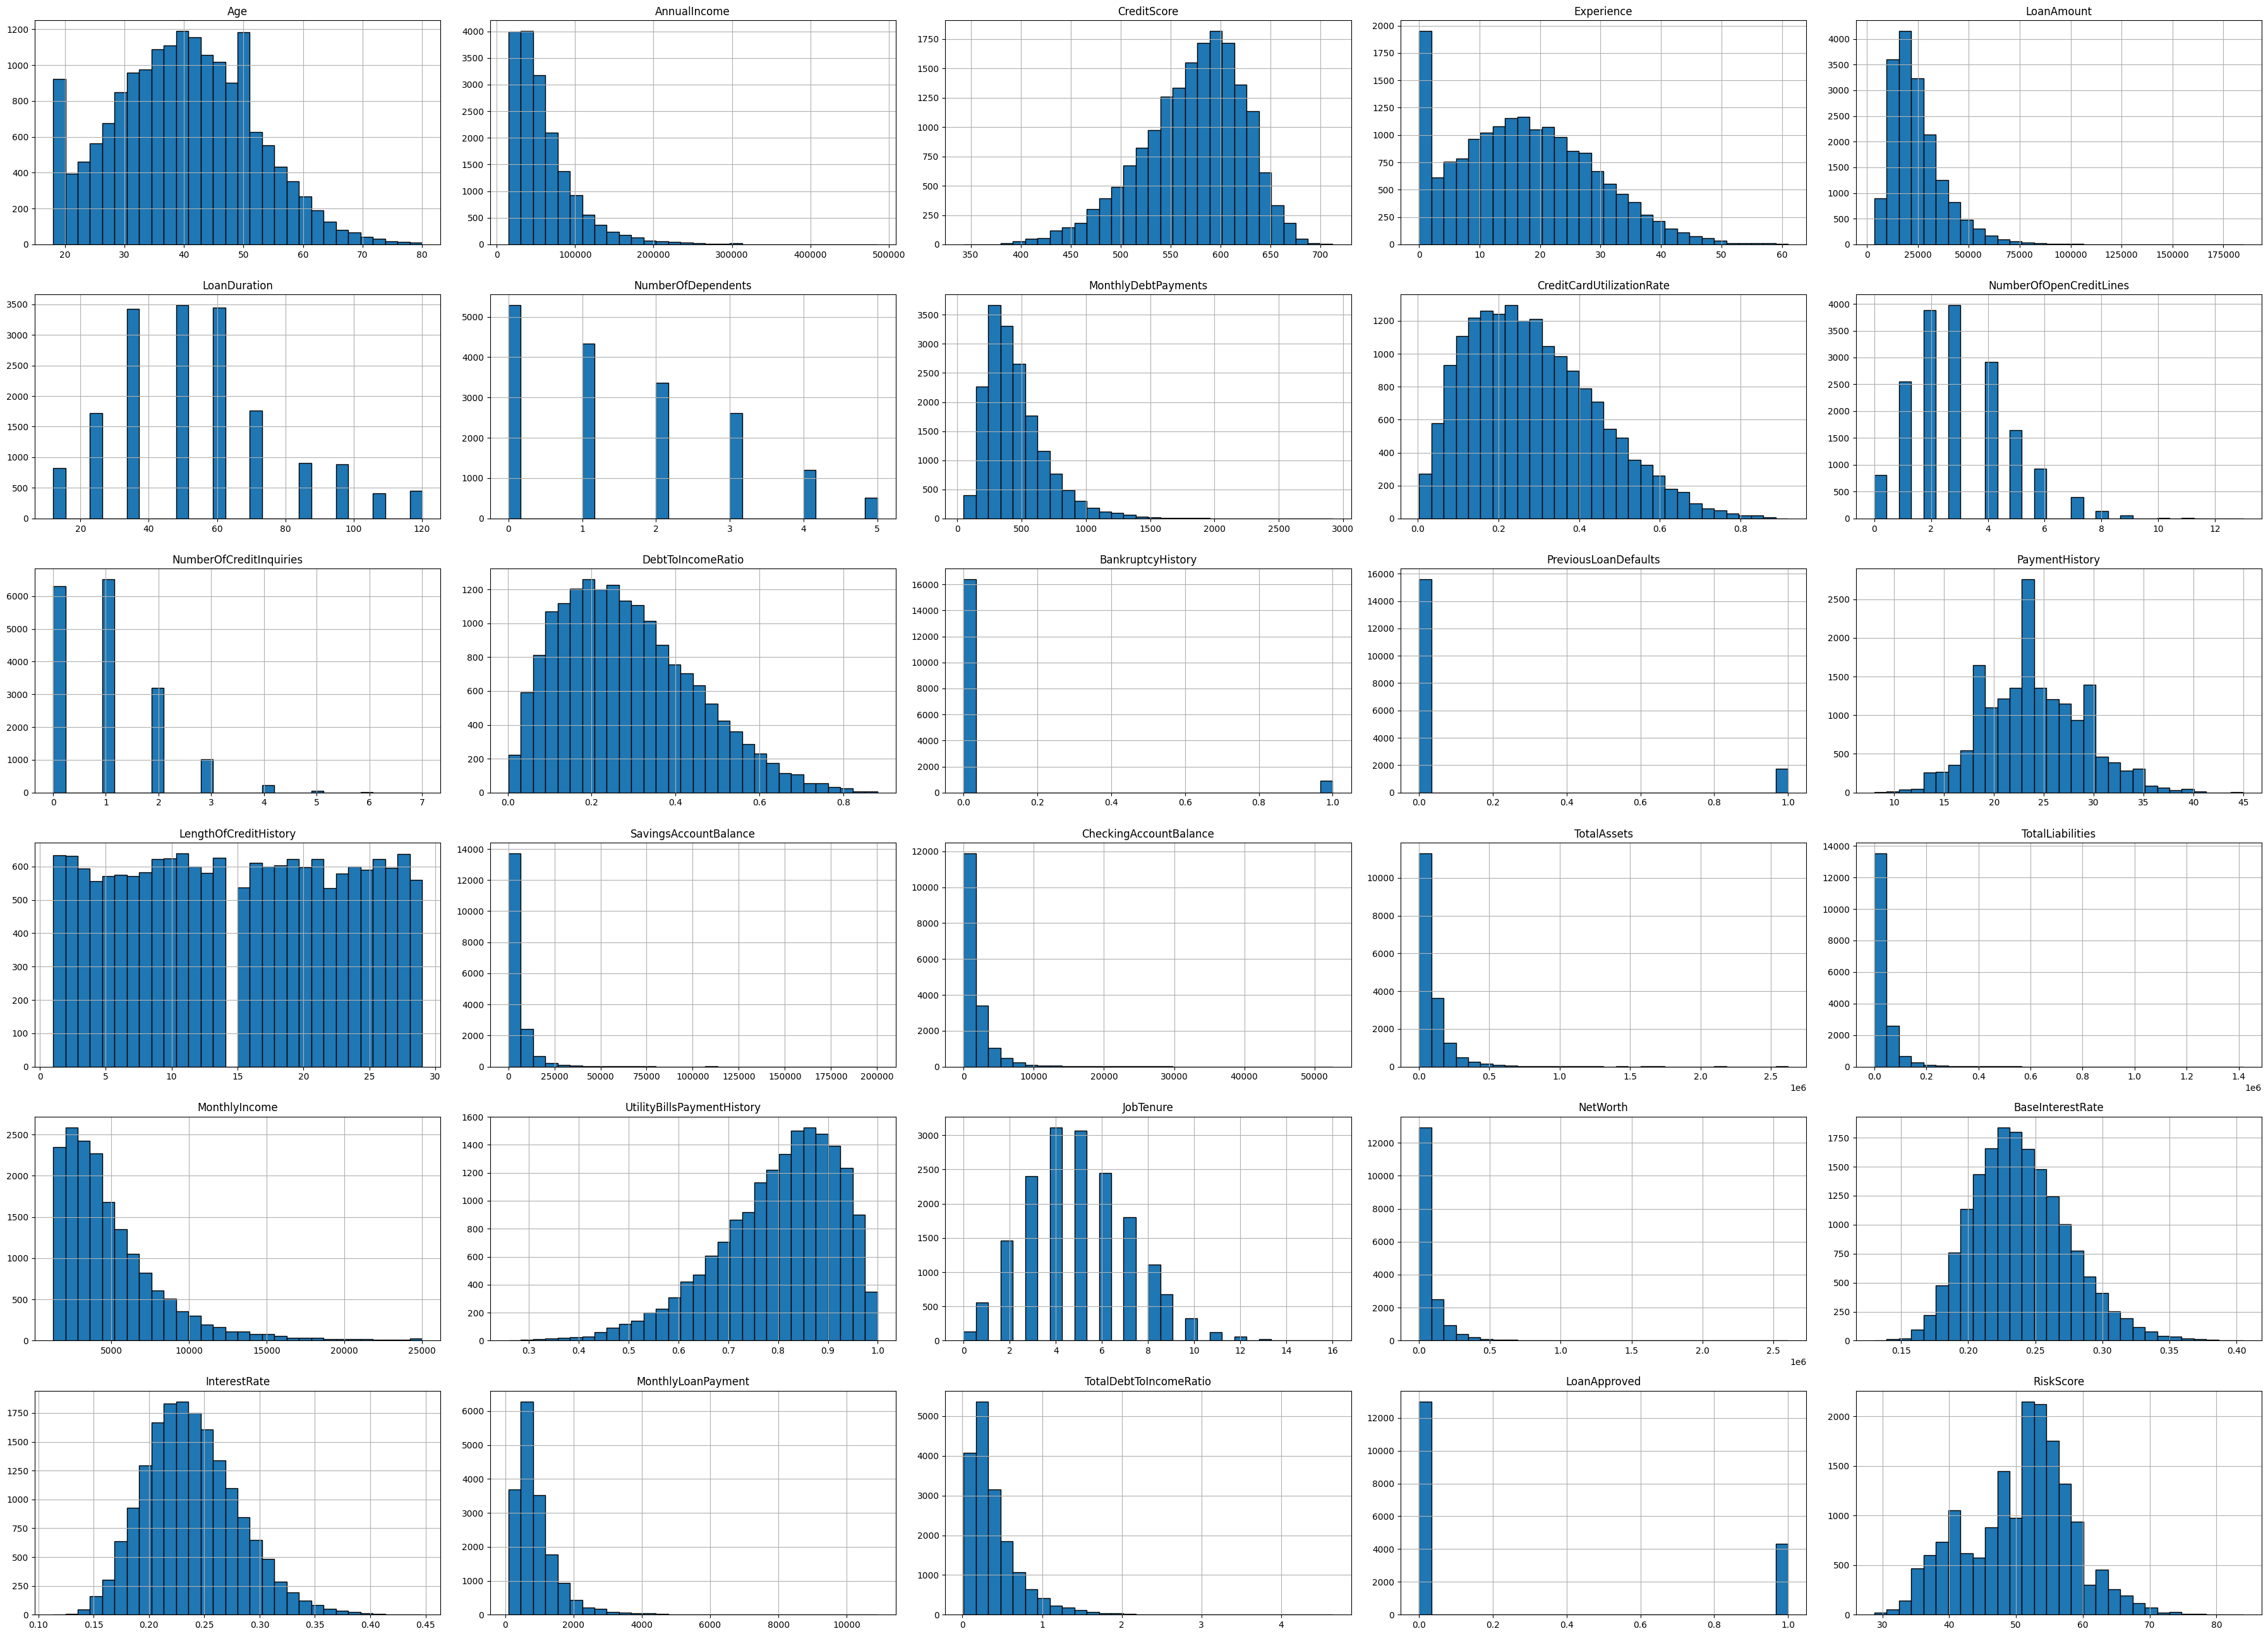

In [181]:
# Numerical Feature Distributions

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_features].hist(
    figsize=(36, 26),
    bins=30,
    edgecolor='black'
)
plt.tight_layout()
plt.show()

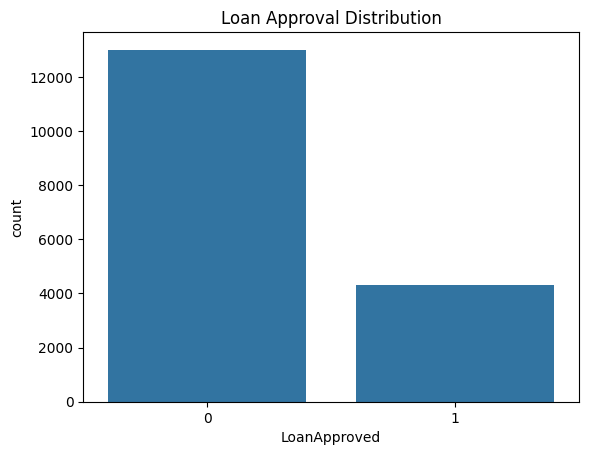

In [182]:
# Target Variable Distribution

sns.countplot(x='LoanApproved', data=df)
plt.title('Loan Approval Distribution')
plt.show()

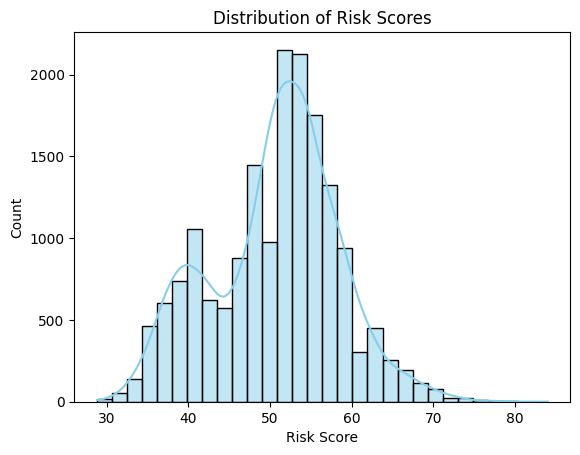

In [183]:
# Risk Score Distribution

sns.histplot(df['RiskScore'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.show()

In [184]:
# Categorical Column Analysis
categorical_columns = df.select_dtypes(include=['object']).columns
print(f'Categorical Columns: {categorical_columns}')

Categorical Columns: Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object')


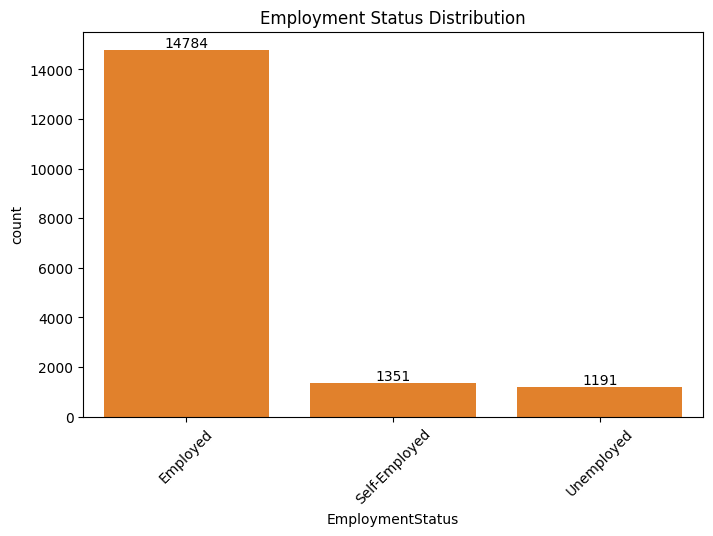

In [185]:
# EmploymentStatus Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='EmploymentStatus', data=df)
plt.title('Employment Status Distribution')
plt.bar_label(sns.countplot(x='EmploymentStatus', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()  

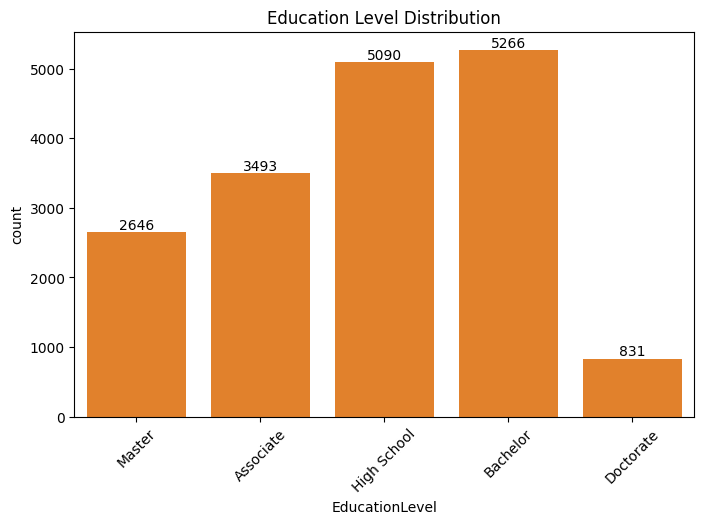

In [186]:
# EducationLevel Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='EducationLevel', data=df) 
plt.title('Education Level Distribution')
plt.bar_label(sns.countplot(x='EducationLevel', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()

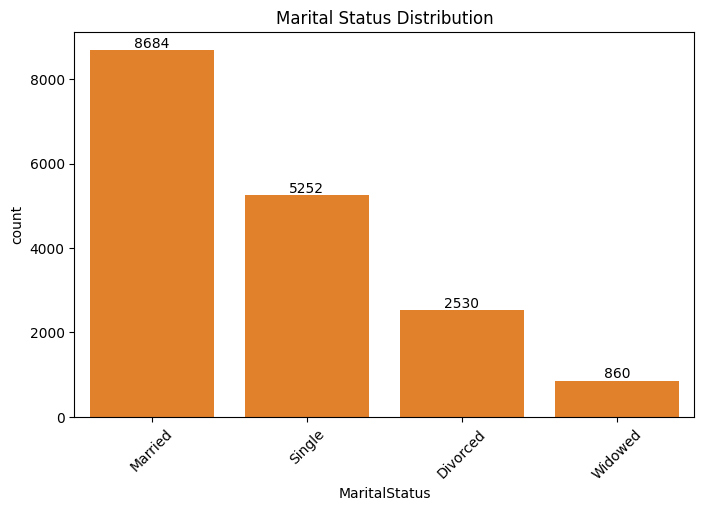

In [187]:
# MaritalStatus Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='MaritalStatus', data=df)   
plt.title('Marital Status Distribution')
plt.bar_label(sns.countplot(x='MaritalStatus', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()

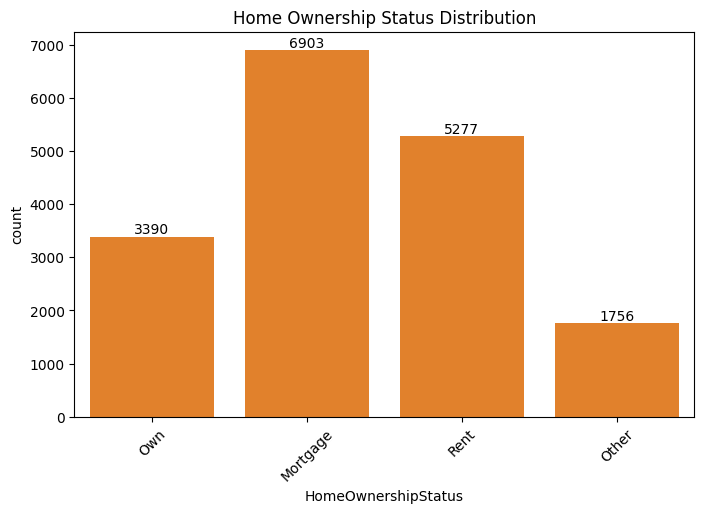

In [188]:
# HomeOwnershipStatus Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='HomeOwnershipStatus', data=df)
plt.title('Home Ownership Status Distribution')
plt.bar_label(sns.countplot(x='HomeOwnershipStatus', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()

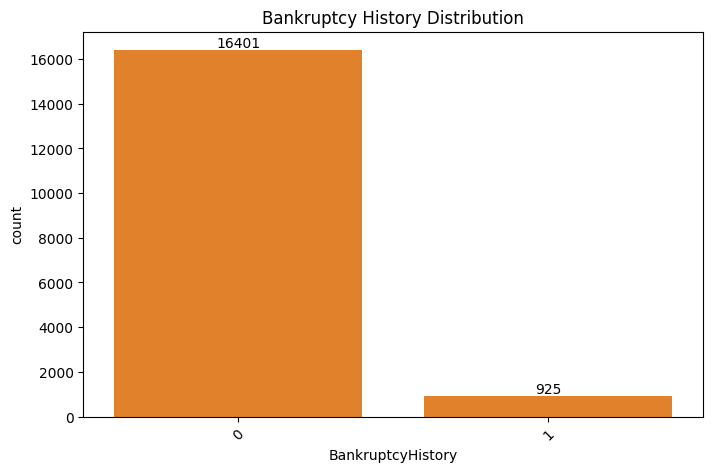

In [189]:
# BankruptcyHistory Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='BankruptcyHistory', data=df)  
plt.title('Bankruptcy History Distribution')
plt.bar_label(sns.countplot(x='BankruptcyHistory', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()

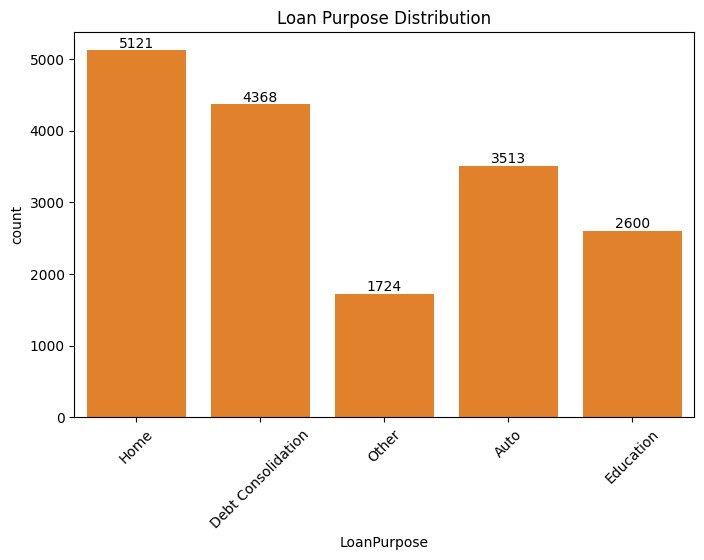

In [190]:
# LoanPurpose Distribution
 
plt.figure(figsize=(8, 5))
sns.countplot(x='LoanPurpose', data=df)
plt.title('Loan Purpose Distribution')
plt.bar_label(sns.countplot(x='LoanPurpose', data=df).containers[0])
plt.xticks(rotation=45)
plt.show()

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [191]:
# Data Prep Code Here - Create New Cells As Needed
numerical_features = ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory',
'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']

categorical_features = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory','LoanPurpose']

X = df.drop(['LoanApproved', 'RiskScore'], axis=1)
y = df['LoanApproved']

In [192]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features: {X.shape[1]}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Features: 33
Target distribution: {0: 13006, 1: 4320}


In [193]:
# Create preprocessing pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create preprocessing pipelines
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine pipelines with ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Preprocessing pipeline created successfully')

Preprocessing pipeline created successfully


In [194]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Train target distribution: {y_train.value_counts().to_dict()}')
print(f'Test target distribution: {y_test.value_counts().to_dict()}')

Training set: (13860, 33)
Test set: (3466, 33)
Train target distribution: {0: 10404, 1: 3456}
Test target distribution: {0: 2602, 1: 864}


In [195]:
# Test preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Processed training set shape: {X_train_processed.shape}')
print(f'Processed test set shape: {X_test_processed.shape}')
print('Data preprocessing completed successfully')

Processed training set shape: (13860, 44)
Processed test set shape: (3466, 44)
Data preprocessing completed successfully


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [196]:
# Create complete modeling pipelines
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Define evaluation metrics
scoring = ['accuracy', 'roc_auc', 'precision', 'recall']
print('Modeling pipelines created successfully')

Modeling pipelines created successfully


In [197]:
# Cross-validation evaluation
from sklearn.model_selection import cross_validate

models = {'RandomForest': rf_pipeline, 'LogisticRegression': lr_pipeline}

for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    print(f'\n{name} Cross-Validation Results:')
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        print(f'{metric}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})')


RandomForest Cross-Validation Results:
accuracy: 0.922 (+/- 0.017)
roc_auc: 0.974 (+/- 0.008)
precision: 0.878 (+/- 0.019)
recall: 0.798 (+/- 0.060)

LogisticRegression Cross-Validation Results:
accuracy: 0.965 (+/- 0.007)
roc_auc: 0.995 (+/- 0.002)
precision: 0.933 (+/- 0.006)
recall: 0.926 (+/- 0.025)


In [198]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Random Forest parameter grid
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

# Logistic Regression parameter grid
lr_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__l1_ratio': [0.0, 0.5, 1.0],
    'classifier__solver': ['saga']
}

print('Parameter grids defined')

Parameter grids defined


In [199]:
# Perform hyperparameter tuning
rf_search = RandomizedSearchCV(rf_pipeline, rf_param_grid, n_iter=10, cv=3, 
                              scoring='roc_auc', random_state=42, n_jobs=-1)

lr_search = GridSearchCV(lr_pipeline, lr_param_grid, cv=3, 
                        scoring='roc_auc', n_jobs=-1)

# Fit the models
print('Training Random Forest...')
rf_search.fit(X_train, y_train)

print('Training Logistic Regression...')
lr_search.fit(X_train, y_train)

print('Hyperparameter tuning completed')

Training Random Forest...
Training Logistic Regression...
Hyperparameter tuning completed


In [200]:

# Best model results
print('Best Random Forest Parameters:')
print(rf_search.best_params_)
print(f'Best RF CV Score: {rf_search.best_score_:.3f}')

print('\nBest Logistic Regression Parameters:')
print(lr_search.best_params_)
print(f'Best LR CV Score: {lr_search.best_score_:.3f}')

# Select best model
if rf_search.best_score_ > lr_search.best_score_:
    best_model = rf_search.best_estimator_
    model_name = 'Random Forest'
else:
    best_model = lr_search.best_estimator_
    model_name = 'Logistic Regression'

print(f'\nBest Model: {model_name}')

Best Random Forest Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 20}
Best RF CV Score: 0.973

Best Logistic Regression Parameters:
{'classifier__C': 1, 'classifier__l1_ratio': 1.0, 'classifier__solver': 'saga'}
Best LR CV Score: 0.995

Best Model: Logistic Regression


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [201]:
# Test set evaluation
from sklearn.metrics import roc_curve, auc

# Make predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Test Set Performance:')
print(f'Accuracy: {test_accuracy:.3f}')
print(f'ROC-AUC: {test_roc_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Test Set Performance:
Accuracy: 0.962
ROC-AUC: 0.994

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2602
           1       0.93      0.92      0.92       864

    accuracy                           0.96      3466
   macro avg       0.95      0.95      0.95      3466
weighted avg       0.96      0.96      0.96      3466



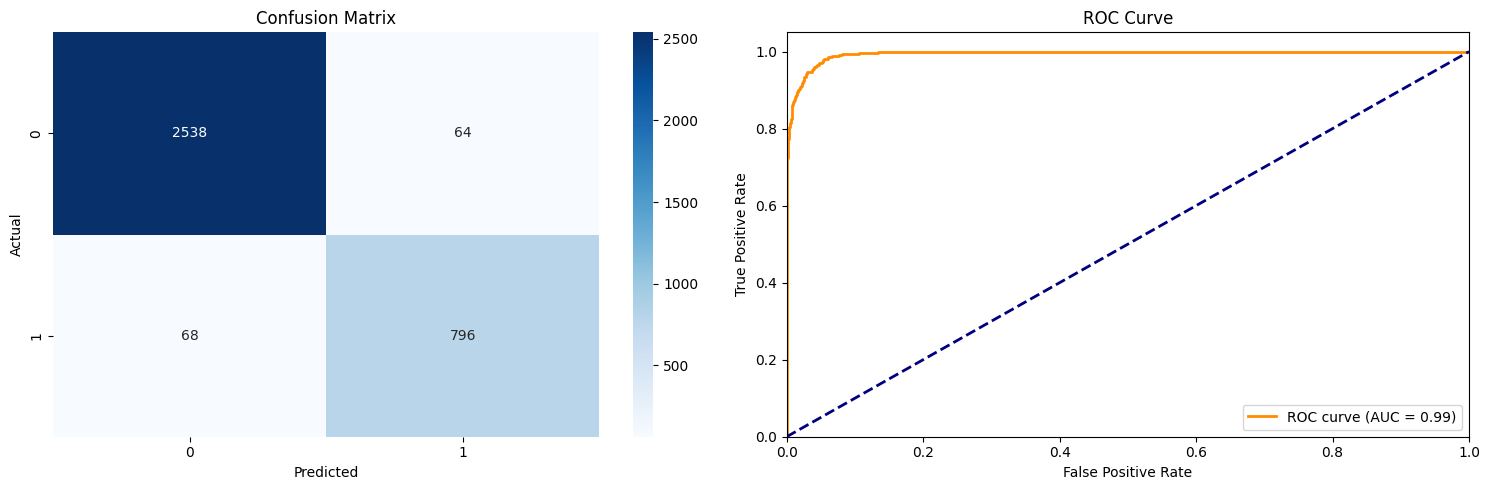

In [202]:
# Model performance visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [217]:
classifier = best_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Extract dynamically generated feature names from OneHotEncoder
    cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features).tolist()
    
    # Reconstruct the complete list of features
    all_feature_names = numerical_features 
    importances = classifier.feature_importances_
    
    # Map importances to feature names
    feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)
    
    # Plot top 10 features
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
    plt.title('Top 10 Most Significant Features')
    plt.tight_layout()
    plt.savefig('feature_importance_final2.png')
    
    print("\n--- Top 5 Business Drivers (Features) ---")
    print(feat_imp_df.head(5))

In [218]:
# Performance across different segments
X_test_with_pred = X_test.copy()
X_test_with_pred['y_true'] = y_test
X_test_with_pred['y_pred'] = y_pred

# Credit score segments
X_test_with_pred['credit_segment'] = pd.cut(X_test_with_pred['CreditScore'], 
                                           bins=[0, 580, 670, 740, 850], 
                                           labels=['Poor', 'Fair', 'Good', 'Excellent'])

print('Performance by Credit Score Segment:')
for segment in X_test_with_pred['credit_segment'].unique():
    if pd.notna(segment):
        mask = X_test_with_pred['credit_segment'] == segment
        segment_accuracy = accuracy_score(X_test_with_pred[mask]['y_true'], 
                                         X_test_with_pred[mask]['y_pred'])
        print(f'{segment}: {segment_accuracy:.3f} (n={mask.sum()})')

Performance by Credit Score Segment:
Fair: 0.958 (n=1603)
Poor: 0.965 (n=1842)
Good: 1.000 (n=21)


9. Extract and interpret feature importance/significance:
- TotalDebtToIncomeRatio, MonthlyIncome, InterestRate, CreditScore, LoanAmount and DebtToIncomeRatio had the most impact on our model.

- These features make strong intuitive sense for credit risk: DebtToIncomeRatios directly measure repayment burden, Income levels reflect ability to service debt, Interest rate reflects the risk pricing assigned by the lender and CreditScore and asset balances provide supporting signals.


10. Final Deliverable Notes & Recommendations
- Data Leakage Warning: I purposely excluded RiskScore from the training pipeline. If RiskScore is calculated dynamically at the time of an application, it can be kept. However, if it contains proprietary calculations derived from the loan outcome itself, it will skew the model to "cheat" (data leakage).

- Business Recommendations: The extracted feature importances indicate that Debt-to-Income ratios and liquid assets heavily influence approval rates. As a business, you can preemptively inform users to consolidate debt prior to applying to improve their automated decision outcomes.

- Potential Improvements: Next steps include deploying the model via an API (using FastAPI or Flask) to integrate with the front-end user application. We can also explore advanced gradient-boosting algorithms (XGBoost/LightGBM) to squeeze out an extra 1-3% accuracy and reduce false positives.